# **Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style = 'whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize' : 16,
    'xtick.labelsize': 11,
    'ytick.labelsize' : 11,
    'figure.titlesize' : 18
})

# **Data Preparation**

In [4]:
# Load the dataset
df = pd.read_excel('/content/drive/MyDrive/Top of mind/Mobile Financial Service Category Data- TV (January,2025- April,2026).xlsx')
#df.head()


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year_Month'] = df['Date'].dt.to_period('M').astype(str)
#df.info()


# **The Macro Share Battle**
**Share of Spend vs. Share of Voice**

In [6]:
# Creating trends
monthly_data = df.groupby(['Year_Month', 'Brand']).agg(
    Monthly_Secs = ('Duration(Sec)', 'sum'),
    Monthly_Spend = ('Cost', 'sum')).reset_index()

totals = df.groupby('Year_Month').agg(
    Cat_Secs = ('Duration(Sec)', 'sum'),
    Cat_Spend = ('Cost', 'sum')).reset_index()

trends = pd.merge(monthly_data, totals, on = 'Year_Month').sort_values('Year_Month')
trends['SOS_%'] = (trends['Monthly_Spend'] / trends['Cat_Spend']) * 100
trends['SOV_%'] = (trends['Monthly_Secs'] / trends['Cat_Secs']) * 100

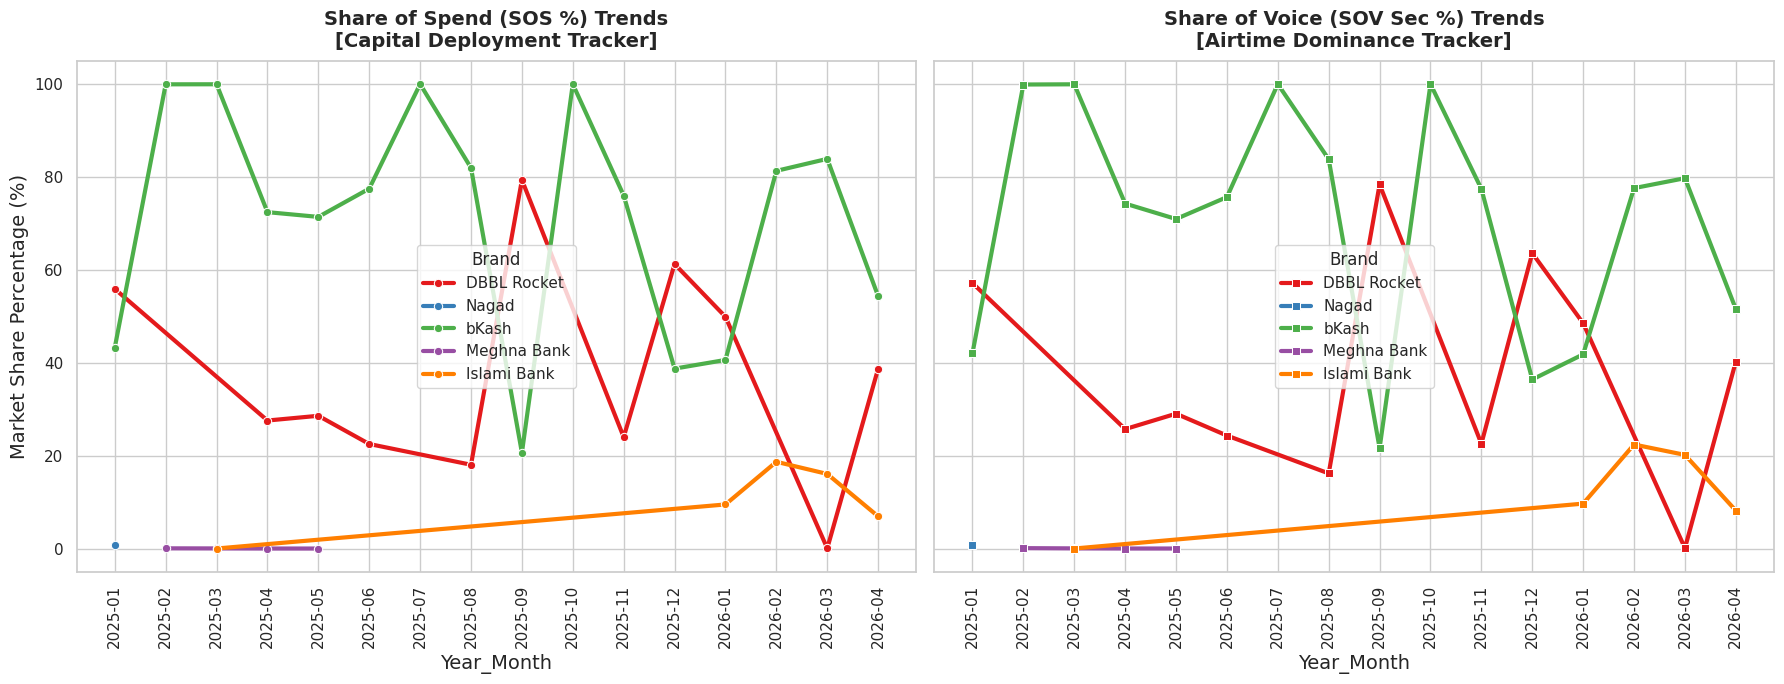

In [7]:
# Ploting
fig, axes = plt.subplots(1,2,
                         figsize = (18, 7),
                         sharey= True)
sns.lineplot(
    data = trends,
    x = 'Year_Month',
    y = 'SOS_%',
    hue = 'Brand',
    marker= 'o',
    linewidth = 3,
    ax = axes[0],
    palette = 'Set1'
    )

axes[0].set_title('Share of Spend (SOS %) Trends\n[Capital Deployment Tracker]',
                  fontsize = 14,
                  fontweight = 'bold',
                  pad = 10)
axes[0].set_ylabel('Market Share Percentage (%)')
axes[0].tick_params(axis = 'x', rotation = 90)


sns.lineplot(
    data = trends,
    x = 'Year_Month',
    y = 'SOV_%',
    hue = 'Brand',
    marker = 's',
    linewidth = 3,
    ax = axes[1],
    palette= 'Set1'
)

axes[1].set_title('Share of Voice (SOV Sec %) Trends\n[Airtime Dominance Tracker]',
                  fontsize = 14,
                  fontweight = 'bold',
                  pad = 10)
axes[1].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()
plt.show()




# **Campaign Continuity Matrix**
**Flighting Density**

In [8]:
# Creating heatmap
days_per_month = df.groupby('Year_Month')['Date'].nunique().reset_index(name = 'Total_Days')
brand_days = df.groupby(['Year_Month', 'Brand'])['Date'].nunique().reset_index(name = 'Active_Days')

continuity = pd.merge(brand_days, days_per_month, on = 'Year_Month')
continuity['Presence_Density_%'] = (continuity['Active_Days'] / continuity['Total_Days']) * 100

heatmap_matrix = continuity.pivot(index = 'Brand',
                                  columns = 'Year_Month',
                                  values = 'Presence_Density_%').fillna(0)

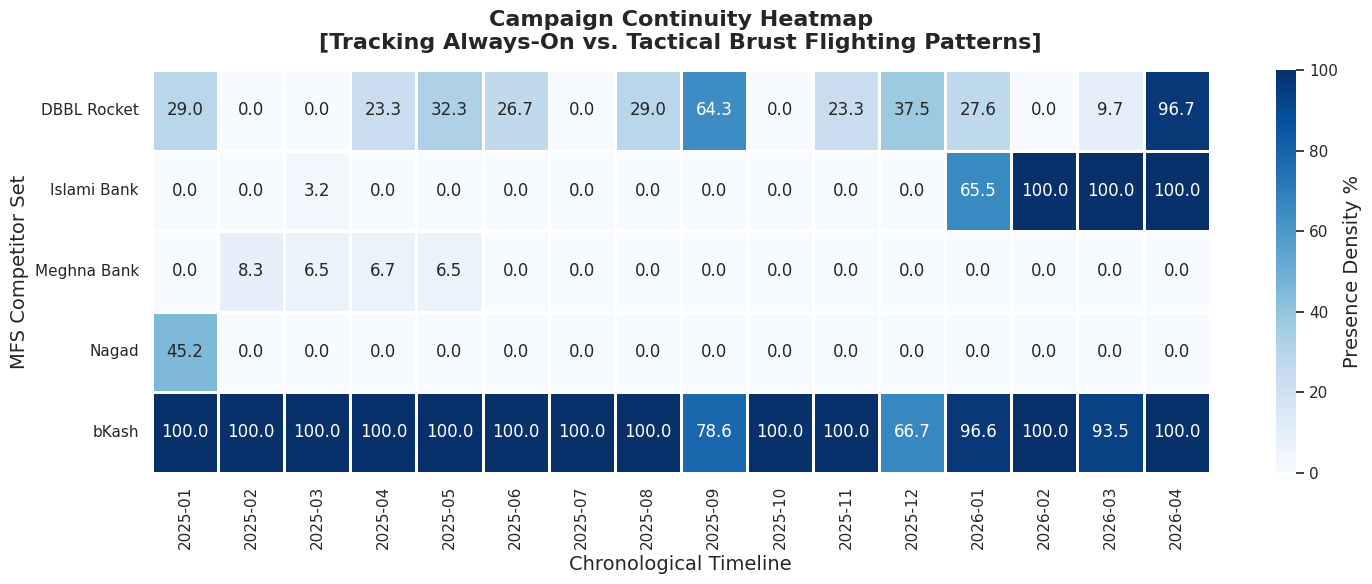

In [9]:
# Heatmap visualization
plt.figure(figsize = (15, 6))
sns.heatmap(heatmap_matrix,
            annot = True,
            fmt = '.1f',
            cmap = 'Blues',
            linewidths = 0.8,
            cbar_kws = {'label': 'Presence Density %'}
            )
plt.title('Campaign Continuity Heatmap\n[Tracking Always-On vs. Tactical Brust Flighting Patterns]',
          fontsize = 16,
          fontweight = 'bold',
          pad = 15)
plt.xlabel('Chronological Timeline')
plt.ylabel('MFS Competitor Set')
plt.tight_layout()
plt.show()


# **The Campaign Theme Portfolio**
**Message to Media Allocation**

In [10]:
#print(df['Commercial Name'].unique())

In [11]:
def classify_campaign_theme(commercial_name):
    name = str(commercial_name).lower()

    # Utility payments (bill, electricity, gas, water)
    if 'bill' in name or 'bidduth' in name or 'gas' in name or 'panir' in name or 'recharge' in name:
        return 'Utility Payments'

    # Cash-out, cashback, charge-free offers
    elif 'cash' in name or 'cashback' in name or 'charge' in name or 'cash out' in name or 'com' in name:
        return 'Cash-Out / Cashback / Pricing Disruption Offers'

    # Festive campaigns (Eid, Ramadan, World Cup, seasonal)
    elif 'eid' in name or 'ramjane' in name or 'ramadan' in name or 'salami' in name or 'bisshocup' in name or 'puja' in name:
        return 'Festive / Seasonal Campaigns'

    # Remittance / international
    elif 'remit' in name or 'probashi' in name or 'bidesh' in name or 'foreign' in name:
        return 'Inbound Remittance'

    # App adoption, DPS, savings, tech ecosystem
    elif 'app' in name or 'download' in name or 'dps' in name or 'savings' in name or 'offer nin' in name:
        return 'App Adoption & Savings Products'

    # Government stipend / financial inclusion
    elif 'vata' in name or 'upobritti' in name or 'scholarship' in name or 'govt' in name or 'shikkha' in name:
        return 'Financial Inclusion / Govt Programs'

    # Merchant payments, lifestyle, everyday use
    elif 'payment' in name or 'super shop' in name or 'merchant' in name or 'kenakata' in name or 'dokan' in name:
        return 'Merchant & Lifestyle Payments'

    # Branding, sponsorships, drama, billboard
    elif 'branding' in name or 'billboard' in name or 'promo' in name or 'talkshow' in name or 'program' in name:
        return 'Brand Equity / Sponsorships'

    # Send money, add money or loan
    elif 'send' in name or 'money' in name or 'add' in name or 'loan' in name:
        return 'Core Peer-to-Peer (P2P) Ecosystem'

    else:
        return 'Core Brand Equity / Corporate'



In [12]:
from textwrap import fill
df['Campaign_Theme'] = df['Commercial Name'].apply(classify_campaign_theme)
theme_mix = df.groupby(['Brand', 'Campaign_Theme'])['Cost'].sum().unstack(fill_value = 0)
theme_mix_pct = theme_mix.div(theme_mix.sum(axis = 1), axis = 0) * 100

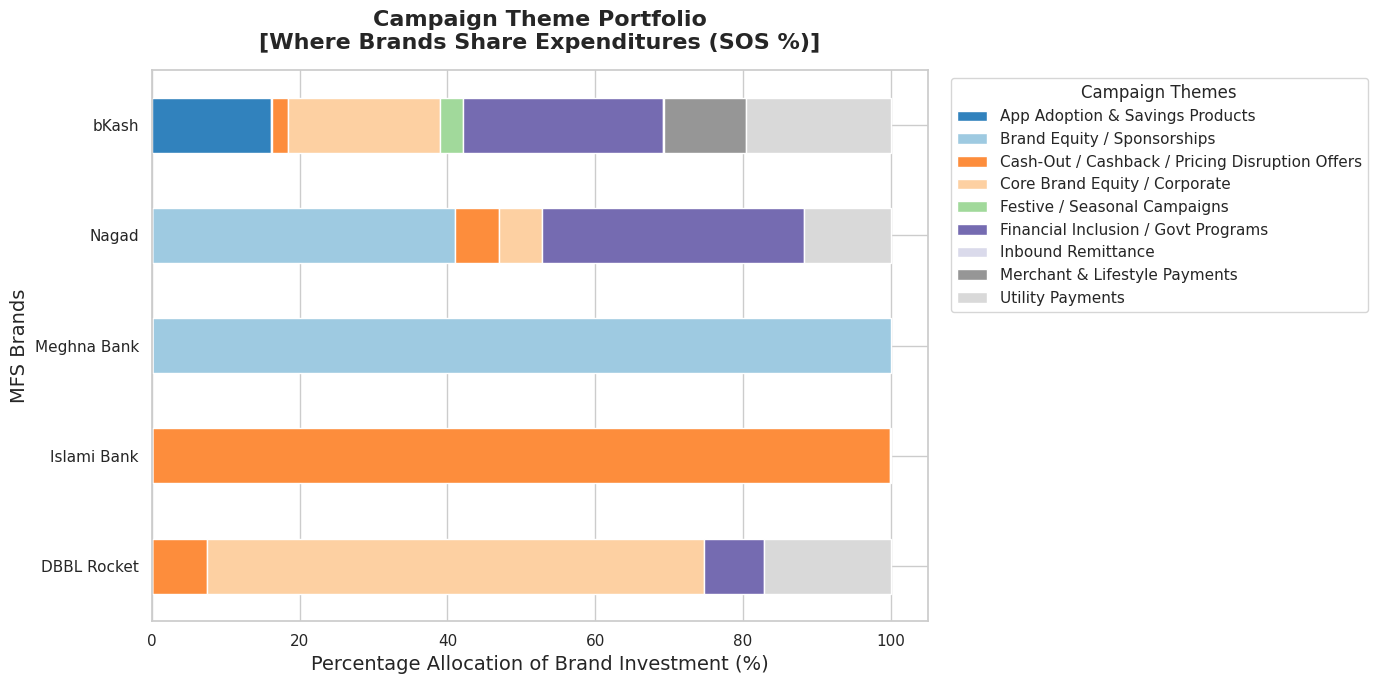

In [13]:
ax = theme_mix_pct.plot(kind = 'barh',
                        stacked = True,
                        figsize = (14, 7),
                        cmap = 'tab20c')

plt.title('Campaign Theme Portfolio\n[Where Brands Share Expenditures (SOS %)]',
           fontsize = 16,
           fontweight = 'bold',
           pad = 15)
plt.xlabel('Percentage Allocation of Brand Investment (%)')
plt.ylabel('MFS Brands')
plt.legend(bbox_to_anchor = (1.02, 1), loc = 'upper left', title = 'Campaign Themes')
plt.tight_layout()
plt.show()



# **The Message Sustainability Matrix**

In [15]:
# Active presence (months active) per theme per brand
sustainability = df.groupby(['Brand', 'Campaign_Theme', 'Year_Month']).size().reset_index(name = 'Spot_Count')
sus_pivot = sustainability.pivot_table(index = ['Brand', 'Campaign_Theme'], columns = 'Year_Month', values = 'Spot_Count', fill_value = 0)
sus_binary = (sus_pivot >  0).astype(int)
#sus_pivot.head()


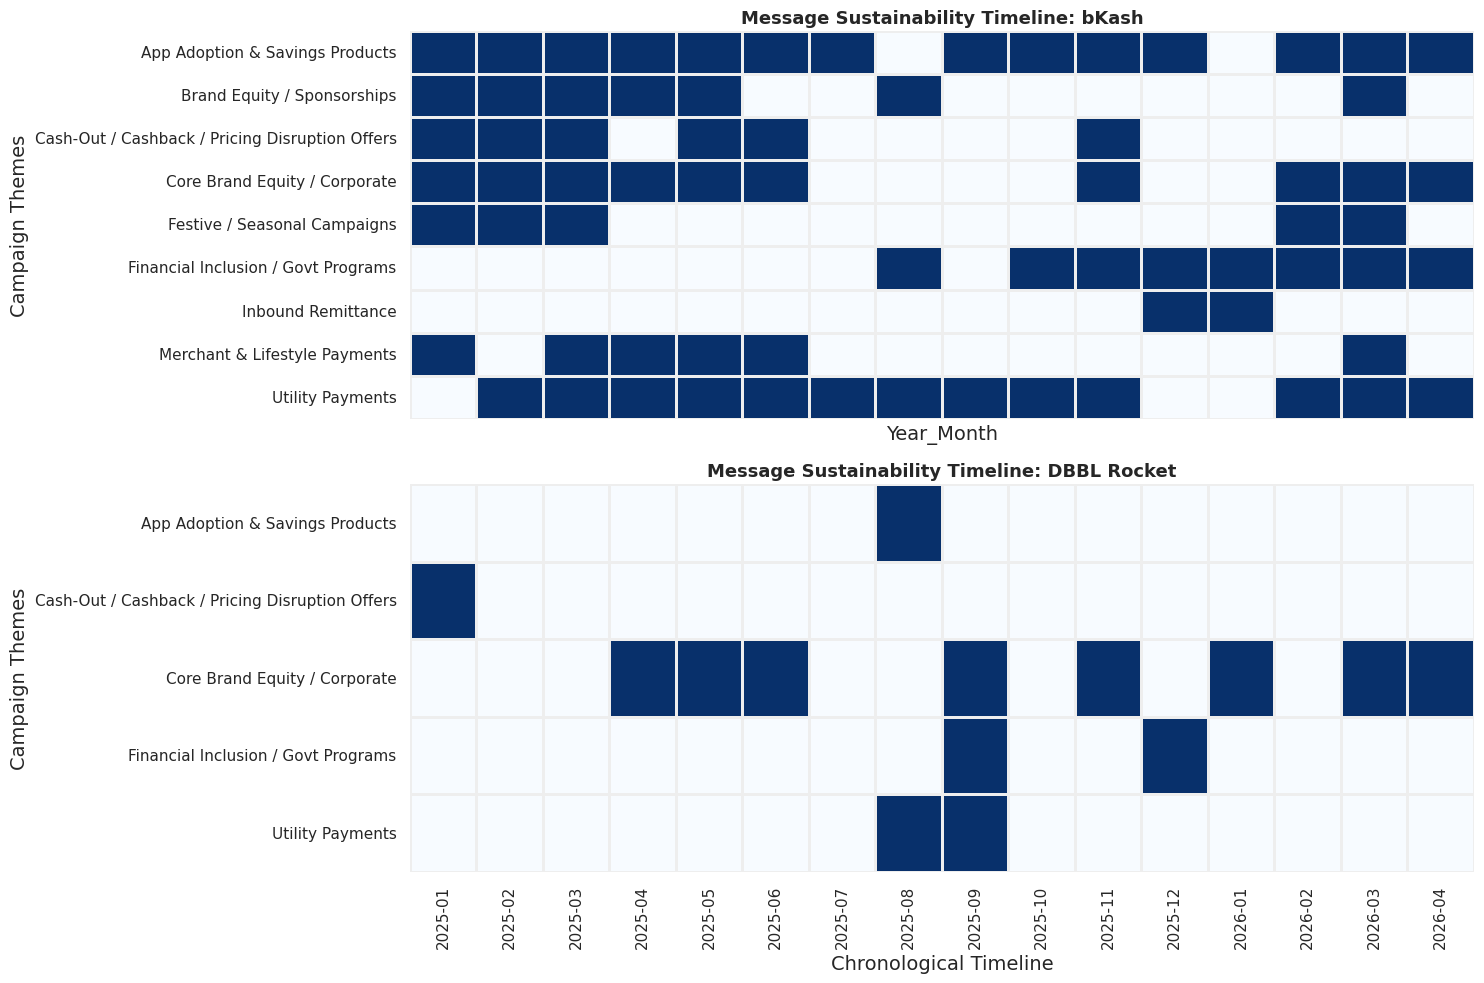

In [16]:
# Filter explicity for bkash vs DBBL Rocket to showcase the strategic contrast
fig, axes = plt.subplots(2,1,
                         figsize = (15, 10),
                         sharex = True)

for i, brand in enumerate(['bKash', 'DBBL Rocket']):
  if brand in sus_binary.index.get_level_values('Brand'):
    brand_matrix = sus_binary.xs(brand, level = 'Brand')
    sns.heatmap(brand_matrix,
            cmap = 'Blues',
            cbar = False,
            linewidths =1,
            linecolor = '#eee',
            ax = axes[i],
            annot = False)
    axes[i].set_title(f'Message Sustainability Timeline: {brand}',
                  fontweight = 'bold',
                  fontsize = 13)
    axes[i].set_ylabel('Campaign Themes')

axes[1].set_xlabel('Chronological Timeline')
axes[1].tick_params(axis = 'x', rotation = 90)
plt.tight_layout()
plt.show()


# **MFS Whitespace Matrix**

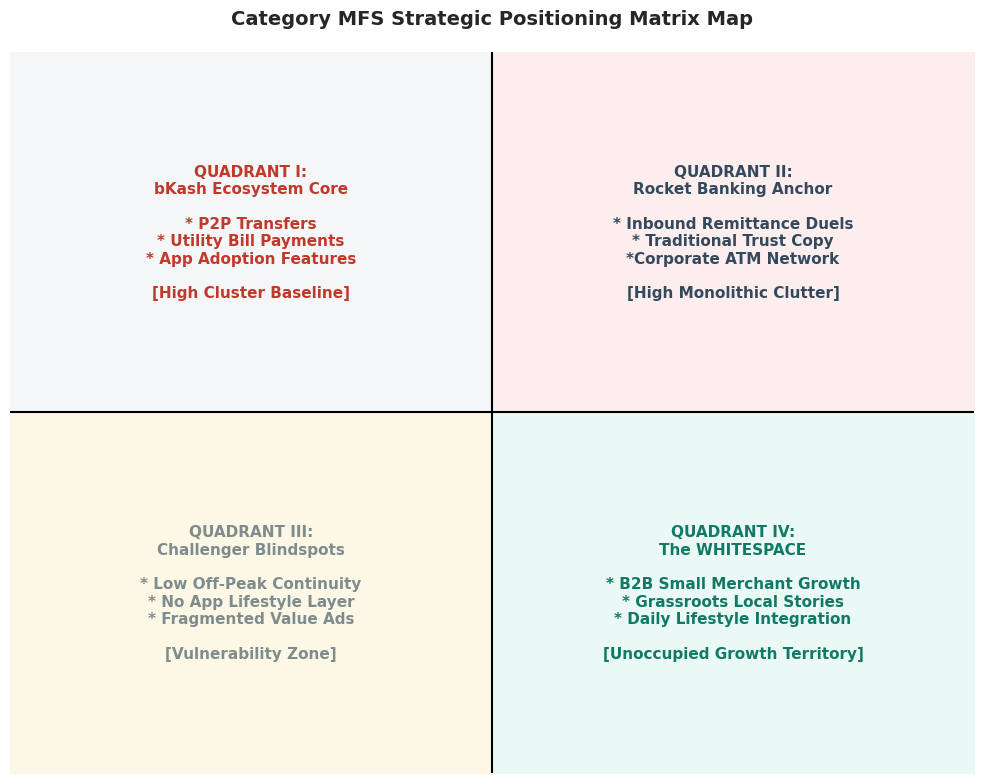

In [17]:
fig, ax = plt.subplots(figsize = (10, 8))
ax.axhline(0, color = 'black', linewidth = 1.5)
ax.axvline(0, color = 'black', linewidth = 1.5)
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.axis('off')
ax.fill_between([0, 10], 0, 10,
                color = '#fdeaea',
                alpha = 0.8)
ax.fill_between([-10, 0], 0, 10,
                color =  '#f3f4f6',
                alpha = 0.8)
ax.fill_between([-10, 0], -10, 0,
                color = '#fcf3cf',
                alpha = 0.5)
ax.fill_between([0, 10], -10, 0,
                color = '#e8f8f5',
                alpha = 0.9)
ax.text(-5, 5,
        'QUADRANT I:\nbKash Ecosystem Core\n\n* P2P Transfers\n* Utility Bill Payments\n* App Adoption Features\n\n[High Cluster Baseline]',
        ha = 'center',
        va = 'center',
        fontsize = 11,
        fontweight = 'bold',
        color = '#c0392b')
ax.text(5,5,
        'QUADRANT II:\nRocket Banking Anchor\n\n* Inbound Remittance Duels\n* Traditional Trust Copy\n*Corporate ATM Network\n\n[High Monolithic Clutter]',
        ha = 'center',
        va = 'center',
        fontsize = 11,
        fontweight = 'bold',
        color = '#34495e')
ax.text(-5,-5,
        'QUADRANT III:\nChallenger Blindspots\n\n* Low Off-Peak Continuity\n* No App Lifestyle Layer\n* Fragmented Value Ads\n\n[Vulnerability Zone]',
        ha = 'center',
        va = 'center',
        fontsize = 11,
        fontweight = 'bold',
        color = '#7f8c8d')
ax.text(5,-5,
        'QUADRANT IV:\nThe WHITESPACE\n\n* B2B Small Merchant Growth\n* Grassroots Local Stories\n* Daily Lifestyle Integration\n\n[Unoccupied Growth Territory]',
        ha = 'center',
        va = 'center',
        fontsize = 11,
        fontweight = 'bold',
        color = '#117a65')

plt.title('Category MFS Strategic Positioning Matrix Map',
          fontsize = 14,
          fontweight = 'bold',
          pad = 20)
plt.tight_layout()
plt.show()


# **Media Investment & Efficiency Analysis**

**Media Efficiency**

In [18]:
df['Hour'] = df['Start Time'].dt.components['hours']
def assign_daypert(hour):
  if pd.isna(hour):
    return 'Other'
  elif 18 <= hour <= 23:
    return 'Prime Time (6PM-12PM)'
  elif 12 <= hour < 18:
    return 'Afternoon (12PM-6PM)'
  elif 6 <= hour < 12:
    return 'Morning (6AM-12AM)'
  else:
    return 'Late Night / Early Morning'

df['Daypart'] = df['Hour'].apply(assign_daypert)

brand_spend = df.groupby('Brand')['Cost'].sum()
sos_pct = (brand_spend / brand_spend.sum()) * 100

if 'TVR' in df.columns and df['TVR'].sum() > 0:
  brand_visibility = df.groupby('Brand')['TVR'].sum()
else:
  brand_visibility = df.groupby('Brand').size()

sov_pct = (brand_visibility / brand_visibility.sum()) * 100
efficiency_df = pd.DataFrame(
    {'Share of Spend (SOS%)': sos_pct, 'Share of Voice (SOV%)': sov_pct}
)

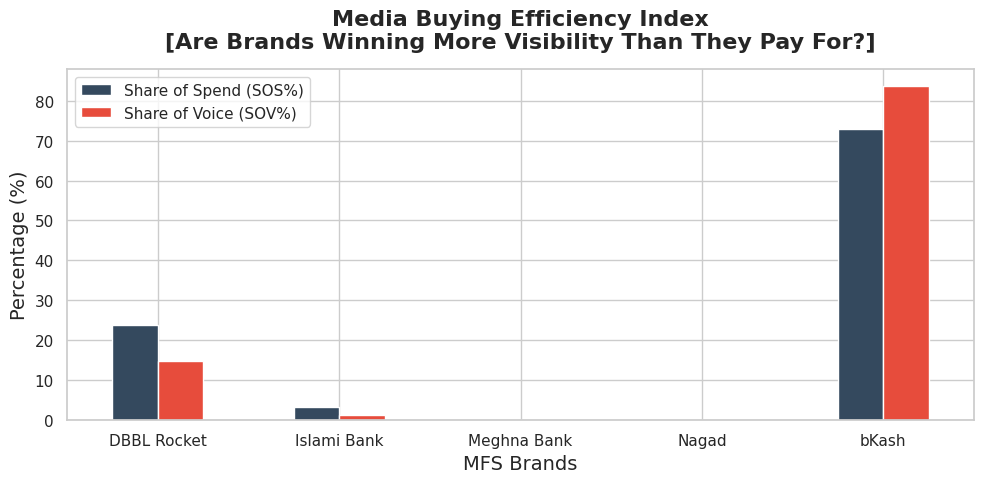

In [19]:
ax1 = efficiency_df.plot(kind = 'bar',
                         figsize = (10, 5),
                         color = ['#34495e', '#e74c3c'])
plt.title('Media Buying Efficiency Index\n[Are Brands Winning More Visibility Than They Pay For?]',
          fontweight= 'bold',
          pad= 15)
plt.ylabel('Percentage (%)')
plt.xlabel('MFS Brands')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()


# **Daypart Strategy**

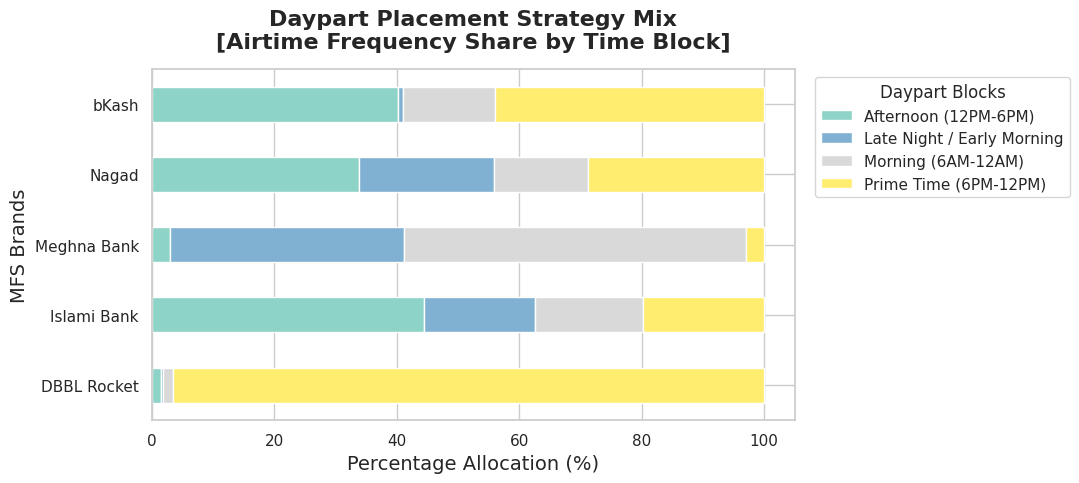

In [20]:
daypart_summary = df.groupby(['Brand', 'Daypart']).size().unstack(fill_value = 0)
daypart_pct = daypart_summary.div(daypart_summary.sum(axis = 1), axis = 0) * 100
ax2 = daypart_pct.plot(kind = 'barh',
                       stacked = True,
                       figsize = (11, 5),
                       cmap = 'Set3')
plt.title('Daypart Placement Strategy Mix\n[Airtime Frequency Share by Time Block]',
          fontweight = 'bold',
          pad = 15)
plt.xlabel('Percentage Allocation (%)')
plt.ylabel('MFS Brands')
plt.legend(bbox_to_anchor = (1.02, 1),
           loc = 'upper left',
           title = 'Daypart Blocks')
plt.tight_layout()
plt.show()

## **That's all**